In [37]:
import pandas as pd
import numpy as np
import os
import glob 
import matplotlib.pyplot as plt

# Parser

In [38]:
def read_mpa_file(filepath):
    realtime = None
    totalsum = None
    roisum = None

    with open(filepath, "r") as f:
        for line in f:
            line = line.strip()
            if line.startswith("REALTIME") and realtime is None:
                realtime = float(line.split()[1].strip())
            elif line.startswith("TOTALSUM") and totalsum is None:
                totalsum = float(line.split()[1].strip())

    return realtime, totalsum

def get_hv(filename):
    name_only = filename.replace("HV", "").replace(".mpa", "")
    name_only = name_only.split("_")[0]
    return int(name_only)

def get_run(filename):
    name_only = filename.replace("HV", "").replace(".mpa", "")
    if "_" in name_only:
        return int(name_only.split("_")[1])
    return 1

data_folder = "HVControl"
rows = []

for filepath in glob.glob(os.path.join(data_folder, "HV*.mpa")):
    filename = os.path.basename(filepath)

    hv = get_hv(filename)
    run = get_run(filename)
    realtime, totalsum = read_mpa_file(filepath)
    rate = totalsum / realtime

    rows.append({
        "hv_volts": hv,
        "run": run,
        "file": filename,
        "realtime_s": realtime,
        "totalsum": totalsum,
        "rate_hz": rate
    })

# Data Collection

In [39]:
df = pd.DataFrame(rows)
df = df.sort_values(["hv_volts", "run"]).reset_index(drop=True)
df

,hv_volts,run,file,realtime_s,totalsum,rate_hz
0,1000,1,HV1000.mpa,150.345,3.0,0.019954
1,1050,1,HV1050.mpa,150.576,7.0,0.046488
2,1100,1,HV1100.mpa,150.349,11.0,0.073163
3,1150,1,HV1150.mpa,150.801,9.0,0.059681
4,1200,1,HV1200.mpa,150.353,6.0,0.039906
...,...,...,...,...,...,...
174,2400,1,HV2400.mpa,151.176,20124.0,133.116368
175,2425,1,HV2425.mpa,150.940,22204.0,147.104810
176,2450,1,HV2450.mpa,150.348,26621.0,177.062548
177,2475,1,HV2475.mpa,151.117,30517.0,201.942865


# Plotting

** The results of Run 1/2 were taken without the float potential turned on 

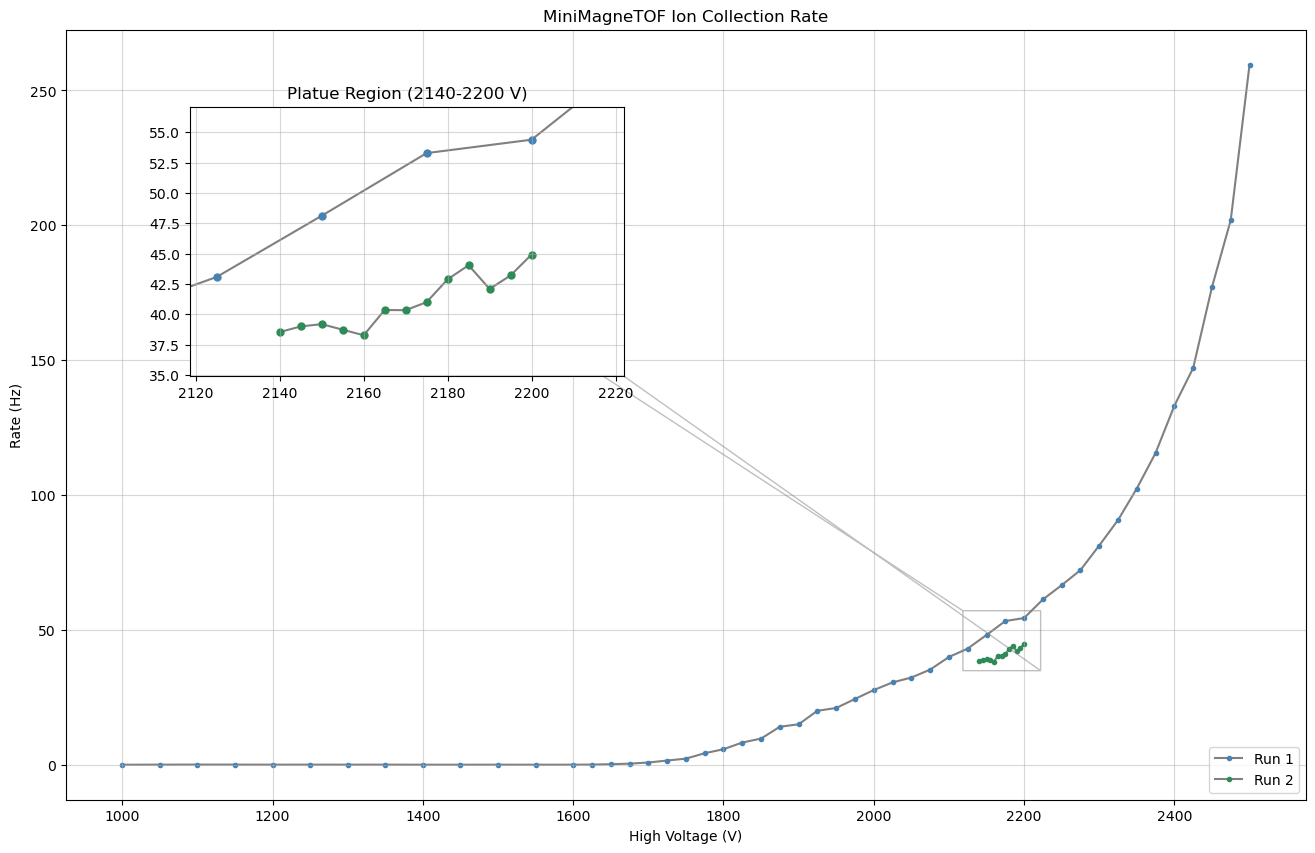

In [40]:
fig, ax = plt.subplots(figsize=(16, 10))

run1 = df[df["run"] == 1]
run2 = df[df["run"] == 2]

# Run 1 Points:
ax.plot(run1["hv_volts"], run1["rate_hz"], linestyle='-', color='gray', zorder=1, marker='o', markersize=3, markerfacecolor='steelblue', markeredgecolor='steelblue', label="Run 1")
# Run 2 Points:
ax.plot(run2["hv_volts"], run2["rate_hz"], linestyle='-', color='gray', zorder=1, marker='o', markersize=3, markerfacecolor='seagreen', markeredgecolor='seagreen', label="Run 2")
ax.set_title("MiniMagneTOF Ion Collection Rate")
ax.set_xlabel("High Voltage (V)")
ax.set_ylabel("Rate (Hz)")
ax.grid(alpha=0.5)
ax.legend(loc="lower right")

ax_inset = ax.inset_axes([0.1, 0.55, 0.35, 0.35])
ax_inset.plot(run1["hv_volts"], run1["rate_hz"], linestyle='-', color='gray', zorder=1, marker='o', markersize=5, markerfacecolor='steelblue', markeredgecolor='steelblue')
ax_inset.plot(run2["hv_volts"], run2["rate_hz"], linestyle='-', color='gray', zorder=1, marker='o', markersize=5, markerfacecolor='seagreen', markeredgecolor='seagreen')
ax_inset.set_xlim(2140 * 0.99, 2200 * 1.01)

mask = (df["hv_volts"] >= 2140) & (df["hv_volts"] <= 2200)
y_in_range = run1.loc[mask, "rate_hz"] 
ax_inset.set_ylim(y_in_range.min() * 0.725, y_in_range.max() * 1.05)
ax_inset.grid(alpha=0.5)
ax_inset.set_title("Platue Region (2140-2200 V)")

ax.indicate_inset_zoom(ax_inset, edgecolor="gray")

plt.show()

In [41]:
# Testing again with the Pump Gauge off and 10V floating potential on. Filament Current set to 0.85A
# Ramping MiniMagneTOF voltage from [1750,2250]
# TDC Threshold set to -0.007V = -7mV

rows = []

tdc_realtime, tdc_totalsum= read_mpa_file(os.path.join(data_folder, "TDCNoise.mpa"))
tdc_noise_rate = tdc_totalsum / tdc_realtime
tdc_noise_err = np.sqrt(tdc_totalsum) / tdc_realtime

#dark_realtime, dark_totalsum = read_mpa_file(os.path.join(data_folder, "DarkCount.mpa"))
#dark_rate = dark_totalsum / dark_realtime
#dark_rate_err = np.sqrt(dark_totalsum) / dark_realtime

#detector_only_dark_rate = dark_rate - tdc_noise_rate
#detector_only_dark_err = np.sqrt(dark_rate_err**2 + tdc_noise_err**2)

print(f"TDC Rate: {tdc_noise_rate:.5f} +/- {tdc_noise_err:.5f} Hz")
#print(f"Dark Rate: {detector_only_dark_rate:.5f} +/- {detector_only_dark_err:.5f} Hz")


for filepath in glob.glob(os.path.join(data_folder, "HV*.mpa")):
    filename = os.path.basename(filepath)
    run = get_run(filename)

    if run not in (4,5):
        continue # skips the old run 1/2 files (floating potential wasn't on) & run 3 as it was operated at a higher current 

    hv = get_hv(filename)
    realtime, totalsum = read_mpa_file(filepath)
    rate = totalsum / realtime


    rows.append({
        "hv_volts": hv,
        "run": run,
        "file": filename,
        "realtime_s": realtime,
        "totalsum": totalsum,
        "rate_hz": rate
    })

df_valid = pd.DataFrame(rows)
df_valid = df_valid.sort_values(["hv_volts", "run"]).reset_index(drop=True)
df_valid["stat_err_hz"] = np.sqrt(df_valid["totalsum"]) / df_valid["realtime_s"]
df_valid["rate_corrected_hz"] = df_valid["rate_hz"]  - tdc_noise_rate # - detector_only_dark_rate
df_valid["total_err_hz"] = np.sqrt(df_valid["stat_err_hz"]**2  + tdc_noise_err**2) #+ detector_only_dark_err**2
df_valid

TDC Rate: 0.01167 +/- 0.00441 Hz


,hv_volts,run,file,realtime_s,totalsum,rate_hz,stat_err_hz,rate_corrected_hz,total_err_hz
0,1750,4,HV1750_4.mpa,150.128,5.0,0.033305,0.014894,0.021640,0.015533
1,1760,4,HV1760_4.mpa,150.125,2.0,0.013322,0.009420,0.001657,0.010401
2,1770,4,HV1770_4.mpa,150.134,3.0,0.019982,0.011537,0.008317,0.012351
3,1780,4,HV1780_4.mpa,150.123,5.0,0.033306,0.014895,0.021641,0.015534
4,1800,4,HV1800_4.mpa,150.141,6.0,0.039962,0.016315,0.028297,0.016900
...,...,...,...,...,...,...,...,...,...
86,2260,5,HV2260_5.mpa,120.095,7401.0,61.626213,0.716342,61.614547,0.716355
87,2270,5,HV2270_5.mpa,120.320,7906.0,65.708112,0.738993,65.696446,0.739007
88,2280,5,HV2280_5.mpa,120.159,8279.0,68.900374,0.757238,68.888708,0.757251
89,2290,5,HV2290_5.mpa,120.428,8697.0,72.217425,0.774386,72.205759,0.774398


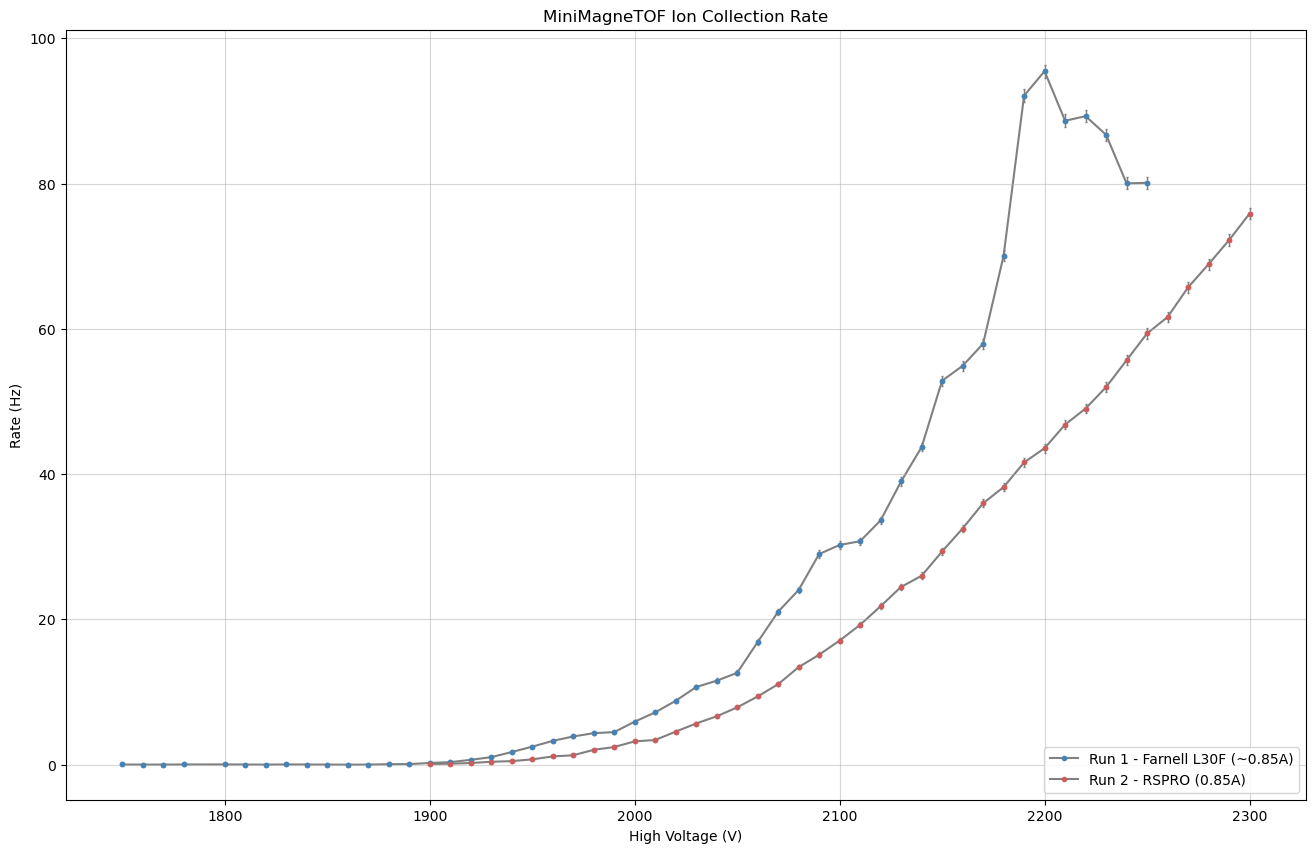

In [51]:
fig, ax = plt.subplots(figsize=(16, 10))

run4 = df_valid[df_valid["run"] == 4]
run5 = df_valid[df_valid["run"] == 5]

# Run 4 Points:
ax.plot(run4["hv_volts"], run4["rate_corrected_hz"], linestyle='-', color='gray', zorder=1, marker='o', markersize=3, markerfacecolor='steelblue', markeredgecolor='steelblue', label="Run 1 - Farnell L30F (~0.85A)")
ax.errorbar(run4["hv_volts"], run4["rate_corrected_hz"], yerr=run4["total_err_hz"], fmt='o', markersize=3, color='steelblue', ecolor='gray', elinewidth=1, capsize=1)
# Run 5 Points:
ax.plot(run5["hv_volts"], run5["rate_corrected_hz"], linestyle='-', color='gray', zorder=1, marker='o', markersize=3, markerfacecolor='indianred', markeredgecolor='indianred', label="Run 2 - RSPRO (0.85A)")
ax.errorbar(run5["hv_volts"], run5["rate_corrected_hz"], yerr=run5["total_err_hz"], fmt='o', markersize=3, color='indianred', ecolor='gray', elinewidth=1, capsize=1)
ax.set_title("MiniMagneTOF Ion Collection Rate")
ax.set_xlabel("High Voltage (V)")
ax.set_ylabel("Rate (Hz)")
ax.grid(alpha=0.5)
ax.legend(loc="lower right")

# ax_inset = ax.inset_axes([0.1, 0.55, 0.35, 0.35])
# ax_inset.plot(run4["hv_volts"], run4["rate_hz"], linestyle='-', color='gray', zorder=1, marker='o', markersize=5, markerfacecolor='seagreen', markeredgecolor='seagreen')
# ax_inset.set_xlim(2000 * 0.99, 2150 * 1.01)

# mask = (run4["hv_volts"] >= 2000) & (run4["hv_volts"] <= 2150)
# y_in_range = run4.loc[mask, "rate_hz"]
# ax_inset.set_ylim(y_in_range.min() * 0.90, y_in_range.max() * 1.10)
# ax_inset.grid(alpha=0.5)
# ax_inset.set_title("Platue Region (2140-2200 V)")

# ax.indicate_inset_zoom(ax_inset, edgecolor="gray")